In [3]:
#CELL 1: Imports & Load 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

df = pd.read_csv(r'C:\Users\matew\OneDrive\Documents\capstone\bei-smart\data\cleaned\bei_smart_classification.csv', 
                 parse_dates=['date', 'date_month'])

# Drop 115 fuel nulls
df = df.dropna(subset=['diesel_price_kes'])
print('Shape after dropping fuel nulls:', df.shape)

Shape after dropping fuel nulls: (16048, 29)


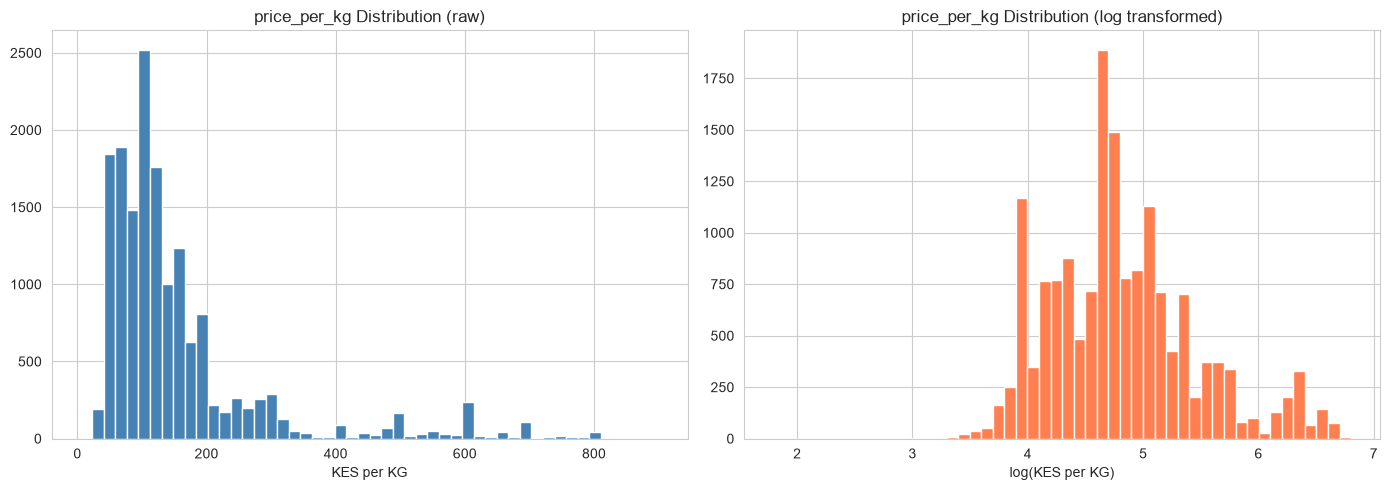

Skewness raw: 2.543
Skewness log: 0.67

Conclusion: skewness > 1 — use log transform before modeling


In [4]:
#Univariate — price_per_kg distribution & skewness
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['price_per_kg'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('price_per_kg Distribution (raw)')
axes[0].set_xlabel('KES per KG')

axes[1].hist(np.log1p(df['price_per_kg']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('price_per_kg Distribution (log transformed)')
axes[1].set_xlabel('log(KES per KG)')

plt.tight_layout()
plt.show()

print('Skewness raw:', df['price_per_kg'].skew().round(3))
print('Skewness log:', np.log1p(df['price_per_kg']).skew().round(3))
print('\nConclusion: skewness > 1 — use log transform before modeling')

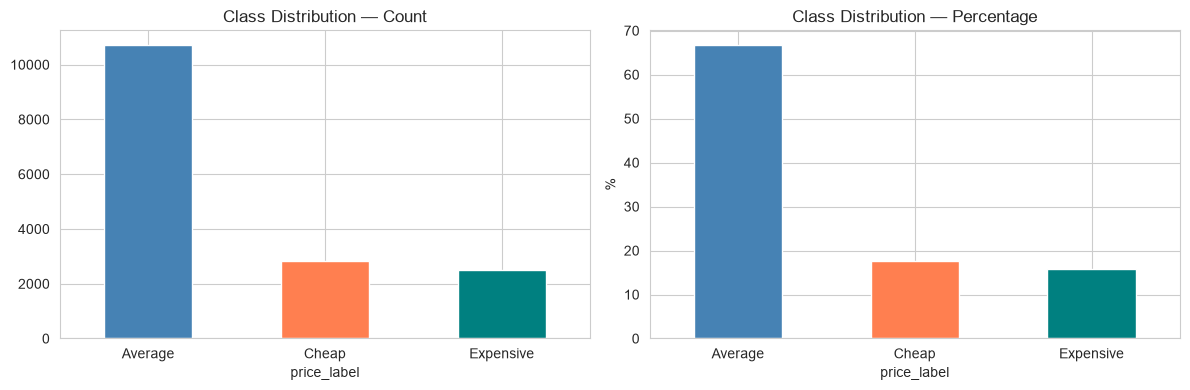

Class balance:
             count   pct
price_label             
Average      10711  66.7
Cheap         2820  17.6
Expensive     2517  15.7

Conclusion: imbalanced — Average dominates at 66.8%. Apply class_weight=balanced in model.


In [5]:
#Class balance check 
counts = df['price_label'].value_counts()
pct = df['price_label'].value_counts(normalize=True).round(3) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'coral', 'teal'])
axes[0].set_title('Class Distribution — Count')
axes[0].tick_params(axis='x', rotation=0)

pct.plot(kind='bar', ax=axes[1], color=['steelblue', 'coral', 'teal'])
axes[1].set_title('Class Distribution — Percentage')
axes[1].tick_params(axis='x', rotation=0)
axes[1].set_ylabel('%')

plt.tight_layout()
plt.show()

print('Class balance:')
print(pd.DataFrame({'count': counts, 'pct': pct}))
print('\nConclusion: imbalanced — Average dominates at 66.8%. Apply class_weight=balanced in model.')

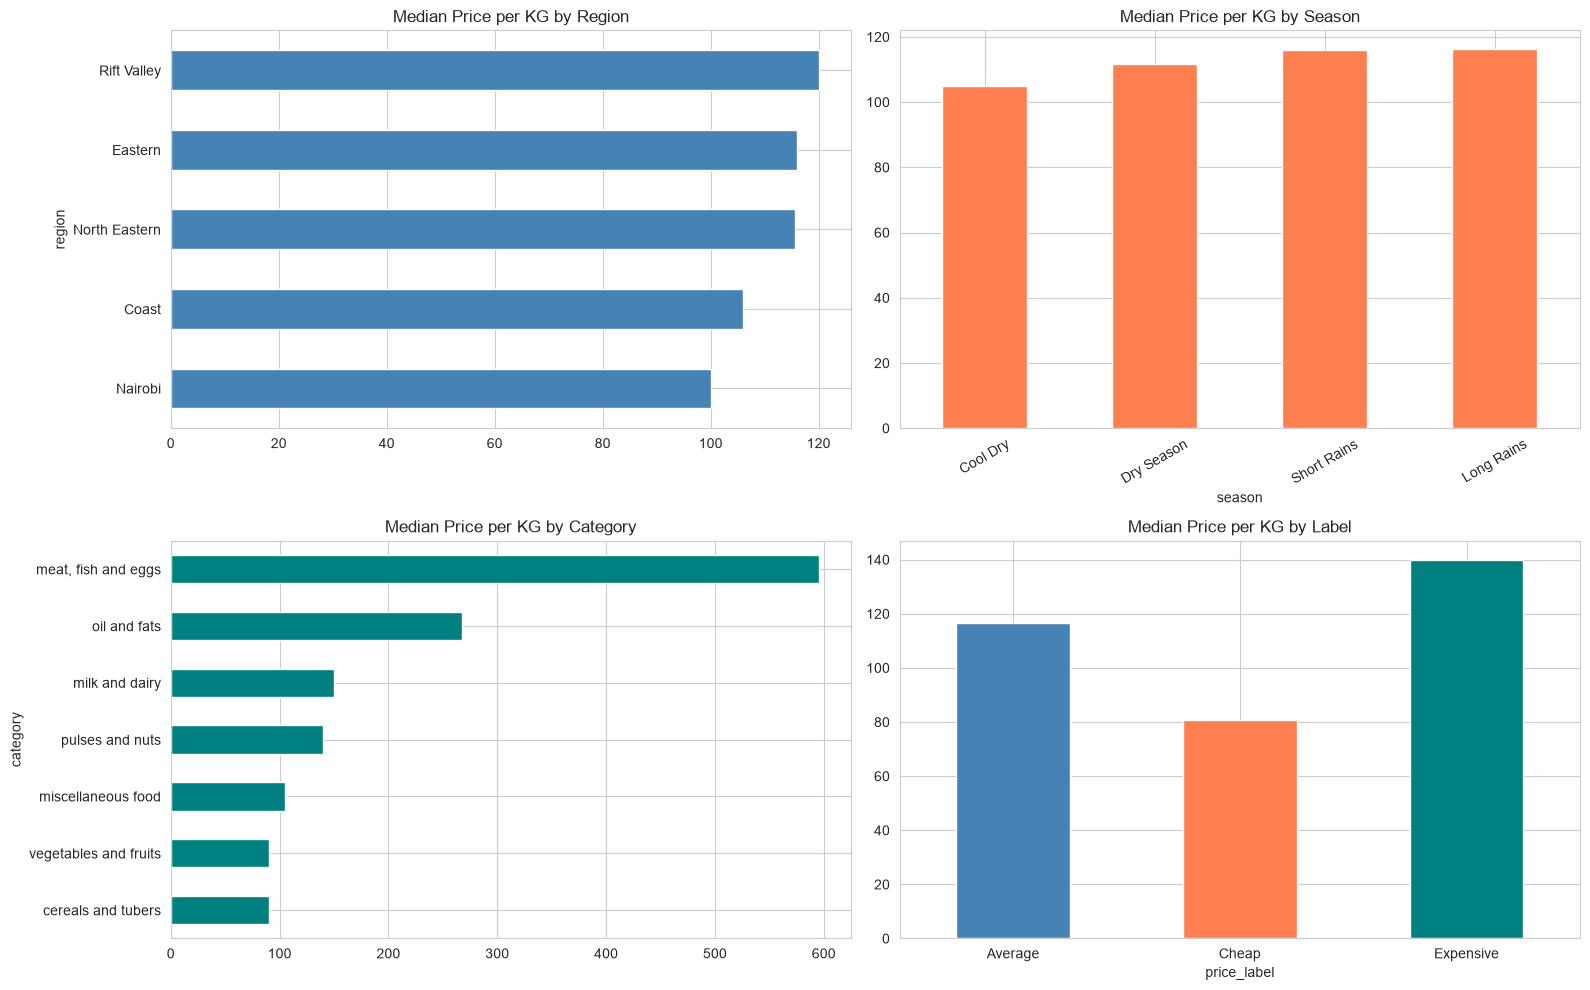

In [6]:
#  Bivariate — price_per_kg vs categorical features
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# vs region
df.groupby('region')['price_per_kg'].median().sort_values().plot(
    kind='barh', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Median Price per KG by Region')

# vs season
df.groupby('season')['price_per_kg'].median().sort_values().plot(
    kind='bar', ax=axes[0,1], color='coral')
axes[0,1].set_title('Median Price per KG by Season')
axes[0,1].tick_params(axis='x', rotation=30)

# vs category
df.groupby('category')['price_per_kg'].median().sort_values().plot(
    kind='barh', ax=axes[1,0], color='teal')
axes[1,0].set_title('Median Price per KG by Category')

# vs price_label
df.groupby('price_label')['price_per_kg'].median().plot(
    kind='bar', ax=axes[1,1], color=['steelblue','coral','teal'])
axes[1,1].set_title('Median Price per KG by Label')
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

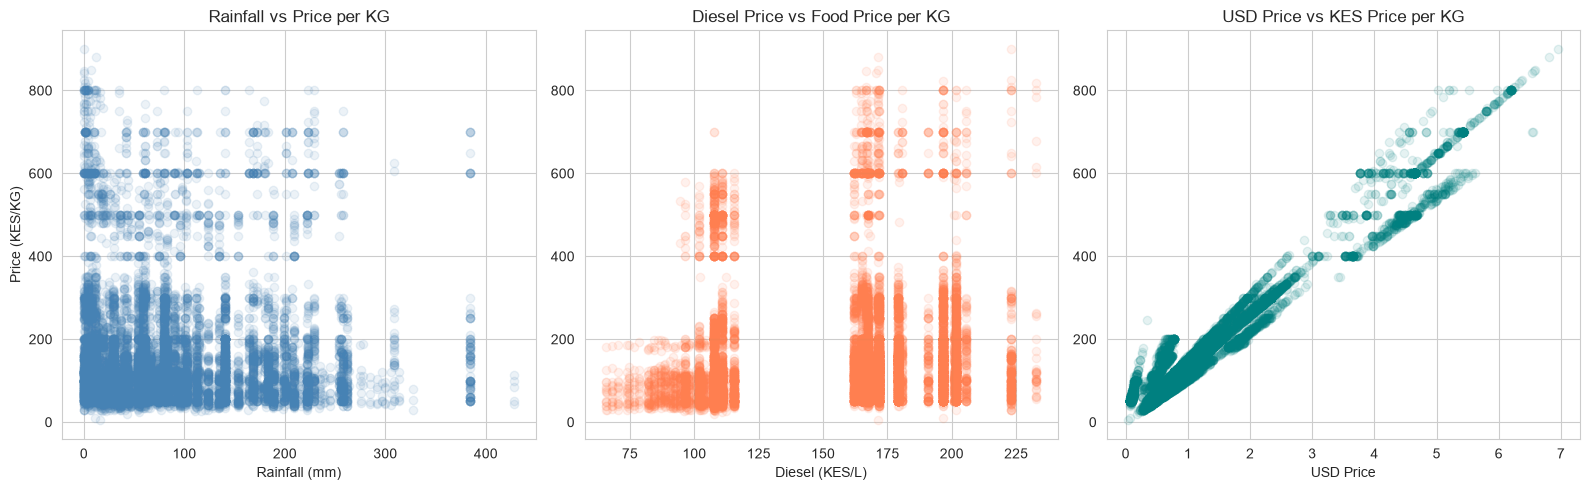

In [ ]:
# CELL 5: Bivariate — price_per_kg vs numeric features
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(df['rainfall_mm'], df['price_per_kg'], alpha=0.1, color='steelblue')
axes[0].set_title('Rainfall vs Price per KG')
axes[0].set_xlabel('Rainfall (mm)')
axes[0].set_ylabel('Price (KES/KG)')

axes[1].scatter(df['diesel_price_kes'], df['price_per_kg'], alpha=0.1, color='coral')
axes[1].set_title('Diesel Price vs Food Price per KG')
axes[1].set_xlabel('Diesel (KES/L)')

axes[2].scatter(df['usdprice'], df['price_per_kg'], alpha=0.1, color='teal')
axes[2].set_title('USD Price vs KES Price per KG')
axes[2].set_xlabel('USD Price')

plt.tight_layout()
plt.show()

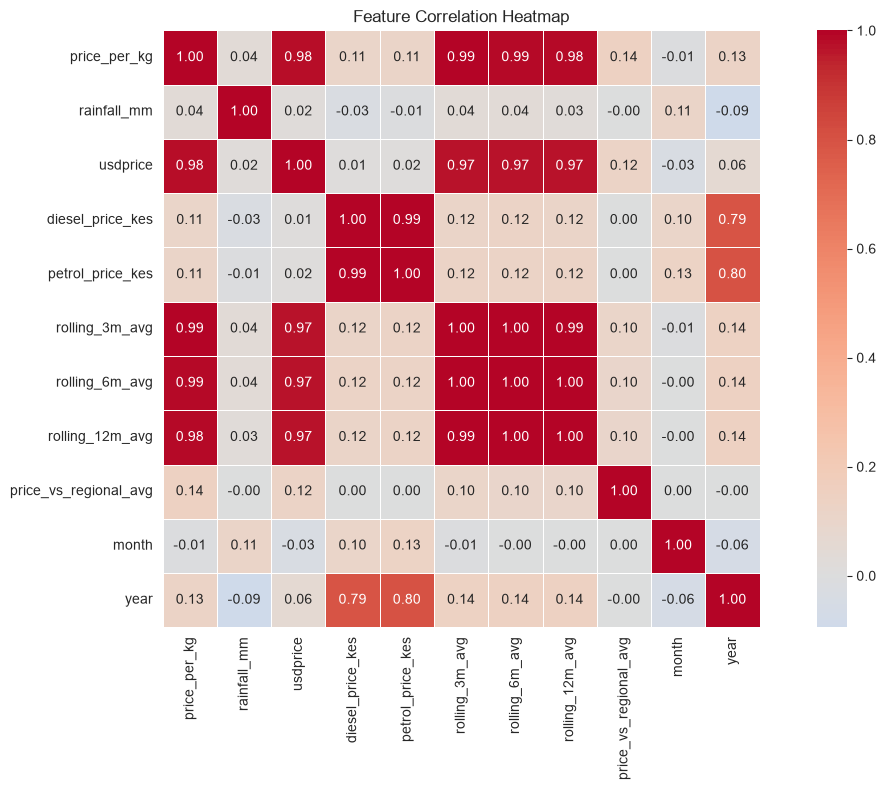

High correlations (>0.85):
  price_per_kg vs usdprice: 0.979 — consider dropping one
  price_per_kg vs rolling_3m_avg: 0.992 — consider dropping one
  price_per_kg vs rolling_6m_avg: 0.988 — consider dropping one
  price_per_kg vs rolling_12m_avg: 0.984 — consider dropping one
  diesel_price_kes vs petrol_price_kes: 0.992 — consider dropping one
  rolling_3m_avg vs usdprice: 0.973 — consider dropping one
  rolling_3m_avg vs rolling_6m_avg: 0.998 — consider dropping one
  rolling_6m_avg vs usdprice: 0.971 — consider dropping one
  rolling_12m_avg vs usdprice: 0.969 — consider dropping one
  rolling_12m_avg vs rolling_3m_avg: 0.994 — consider dropping one
  rolling_12m_avg vs rolling_6m_avg: 0.998 — consider dropping one


In [8]:
#CELL 6: Correlation heatmap
corr_cols = ['price_per_kg', 'rainfall_mm', 'usdprice', 
             'diesel_price_kes', 'petrol_price_kes',
             'rolling_3m_avg', 'rolling_6m_avg', 'rolling_12m_avg',
             'price_vs_regional_avg', 'month', 'year']

corr = df[corr_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# Flag high correlations
print('High correlations (>0.85):')
for col1 in corr_cols:
    for col2 in corr_cols:
        if col1 < col2:
            val = corr.loc[col1, col2]
            if abs(val) > 0.85:
                print(f'  {col1} vs {col2}: {val:.3f} — consider dropping one')

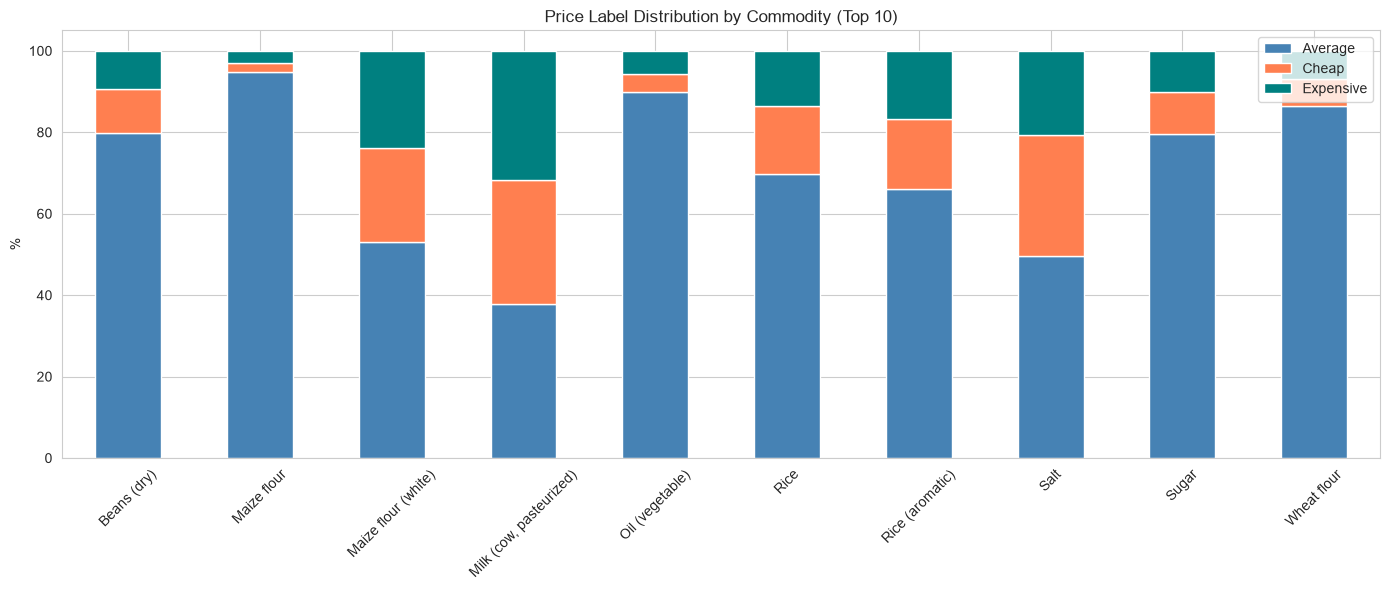

In [9]:
# CELL 7: Price label by commodity (top 10) 
top_commodities = df['commodity'].value_counts().head(10).index
df_top = df[df['commodity'].isin(top_commodities)]

ct = pd.crosstab(df_top['commodity'], df_top['price_label'], normalize='index') * 100

ct.plot(kind='bar', stacked=True, figsize=(14, 6), 
        color=['steelblue', 'coral', 'teal'])
plt.title('Price Label Distribution by Commodity (Top 10)')
plt.xlabel('')
plt.ylabel('%')
plt.legend(loc='upper right')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

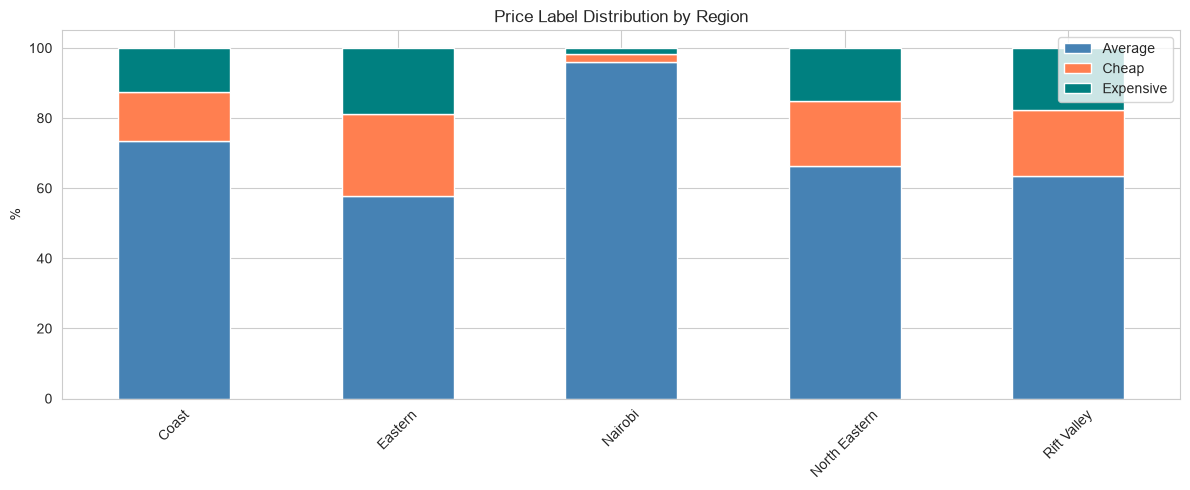

In [10]:
#  Price label by region 
ct_region = pd.crosstab(df['region'], df['price_label'], normalize='index') * 100

ct_region.plot(kind='bar', stacked=True, figsize=(12, 5),
               color=['steelblue', 'coral', 'teal'])
plt.title('Price Label Distribution by Region')
plt.xlabel('')
plt.ylabel('%')
plt.legend(loc='upper right')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

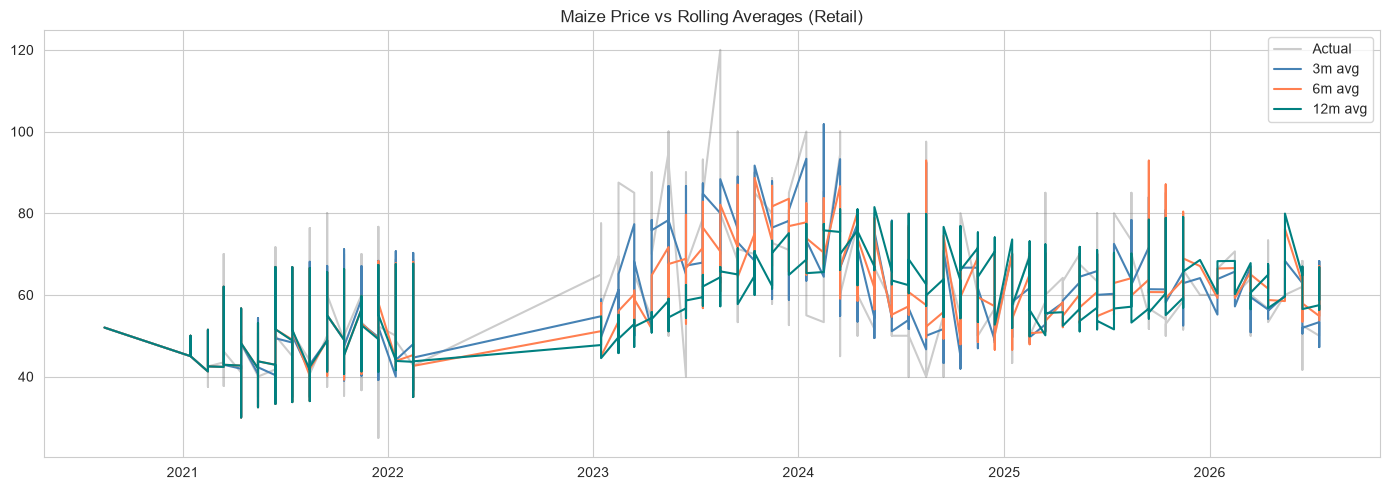

In [11]:
#  Rolling averages vs price_per_kg 
sample = df[df['commodity'] == 'Maize'].copy()
sample = sample.sort_values('date')

plt.figure(figsize=(14, 5))
plt.plot(sample['date'], sample['price_per_kg'], alpha=0.4, label='Actual', color='grey')
plt.plot(sample['date'], sample['rolling_3m_avg'], label='3m avg', color='steelblue')
plt.plot(sample['date'], sample['rolling_6m_avg'], label='6m avg', color='coral')
plt.plot(sample['date'], sample['rolling_12m_avg'], label='12m avg', color='teal')
plt.title('Maize Price vs Rolling Averages (Retail)')
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
# Key modeling decisions summary 
print('=== MODELING DECISIONS FROM EDA ===')
print()
print('1. Target: price_label (Cheap / Average / Expensive)')
print()
print('2. Log transform price_per_kg before modeling')
print(f'   Raw skewness: {df["price_per_kg"].skew():.2f} → log skewness: {np.log1p(df["price_per_kg"]).skew():.2f}')
print()
print('3. Class imbalance — use class_weight=balanced in classifier')
print(f'   Average: {(df["price_label"]=="Average").mean()*100:.1f}%')
print(f'   Cheap:   {(df["price_label"]=="Cheap").mean()*100:.1f}%')
print(f'   Expensive:{(df["price_label"]=="Expensive").mean()*100:.1f}%')
print()
print('4. Drop one of petrol/diesel — highly correlated')
print()
print('5. Drop one of rolling_3m / rolling_6m / rolling_12m if corr > 0.85')
print()
print('6. Features to use in model:')
features = ['region', 'commodity', 'market', 'season', 'month', 'year',
            'rainfall_mm', 'diesel_price_kes', 'rolling_3m_avg', 
            'rolling_12m_avg', 'price_vs_regional_avg', 'latitude', 'longitude']
print('  ', features)

=== MODELING DECISIONS FROM EDA ===

1. Target: price_label (Cheap / Average / Expensive)

2. Log transform price_per_kg before modeling
   Raw skewness: 2.54 → log skewness: 0.67

3. Class imbalance — use class_weight=balanced in classifier
   Average: 66.7%
   Cheap:   17.6%
   Expensive:15.7%

4. Drop one of petrol/diesel — highly correlated

5. Drop one of rolling_3m / rolling_6m / rolling_12m if corr > 0.85

6. Features to use in model:
   ['region', 'commodity', 'market', 'season', 'month', 'year', 'rainfall_mm', 'diesel_price_kes', 'rolling_3m_avg', 'rolling_12m_avg', 'price_vs_regional_avg', 'latitude', 'longitude']


In [13]:
# ── Final feature selection ───────────────────────────────────────
drop_cols = ['usdprice', 'petrol_price_kes', 'rolling_3m_avg', 'rolling_6m_avg']

df_model = df.drop(columns=drop_cols)

features = [
    'region', 'commodity', 'market', 'season', 'month', 'year',
    'rainfall_mm', 'diesel_price_kes', 'rolling_12m_avg',
    'price_vs_regional_avg', 'latitude', 'longitude'
]

target = 'price_label'

X = df_model[features]
y = df_model[target]

print('X shape:', X.shape)
print('y distribution:\n', y.value_counts())
print('\nFeatures ready for modeling.')

X shape: (16048, 12)
y distribution:
 price_label
Average      10711
Cheap         2820
Expensive     2517
Name: count, dtype: int64

Features ready for modeling.


In [14]:

# Load forecasting dataset
df_fc = pd.read_csv(r'C:\Users\matew\OneDrive\Documents\capstone\bei-smart\data\cleaned\bei_smart_forecasting.csv',
                    parse_dates=['date'])

# Focus on one commodity + market for SARIMA check
# Maize in Nairobi — most complete series
maize_nairobi = df_fc[
    (df_fc['commodity'] == 'Maize') & 
    (df_fc['market'] == 'Nairobi') &
    (df_fc['pricetype'] == 'Wholesale')
].sort_values('date').copy()

print('Maize Nairobi records:', len(maize_nairobi))
print('Date range:', maize_nairobi['date'].min(), 'to', maize_nairobi['date'].max())
print('Missing months:', maize_nairobi['date'].dt.to_period('M').nunique())

Maize Nairobi records: 189
Date range: 2006-01-15 00:00:00 to 2022-03-15 00:00:00
Missing months: 189


In [15]:
# Check what pricetype and date range exists for Maize Nairobi
print(df_fc[df_fc['commodity'] == 'Maize'].groupby(['market', 'pricetype'])['date'].agg(['min', 'max', 'count']))

                                            min        max  count
market                     pricetype                             
Bangladesh (Mombasa)       Retail    2021-04-15 2021-11-15      5
Dagahaley (Daadab)         Retail    2021-01-15 2026-05-15     22
Dandora (Nairobi)          Retail    2021-02-15 2022-01-15     12
Eldoret town (Uasin Gishu) Wholesale 2006-01-15 2022-04-15    188
Ethiopia (Kakuma)          Retail    2021-02-15 2026-08-15     44
Garissa town (Garissa)     Retail    2021-03-15 2022-02-15      9
Hagadera (Daadab)          Retail    2021-01-15 2026-07-15     47
HongKong (Kakuma)          Retail    2021-02-15 2026-08-15     42
IFO (Daadab)               Retail    2021-03-15 2026-08-15     53
Isiolo town                Retail    2021-02-15 2021-11-15      6
Junda (Mombasa)            Retail    2021-04-15 2021-11-15      6
Kakuma 2                   Retail    2021-02-15 2026-08-15     47
Kakuma 3                   Retail    2021-02-15 2026-08-15     49
Kakuma 4  

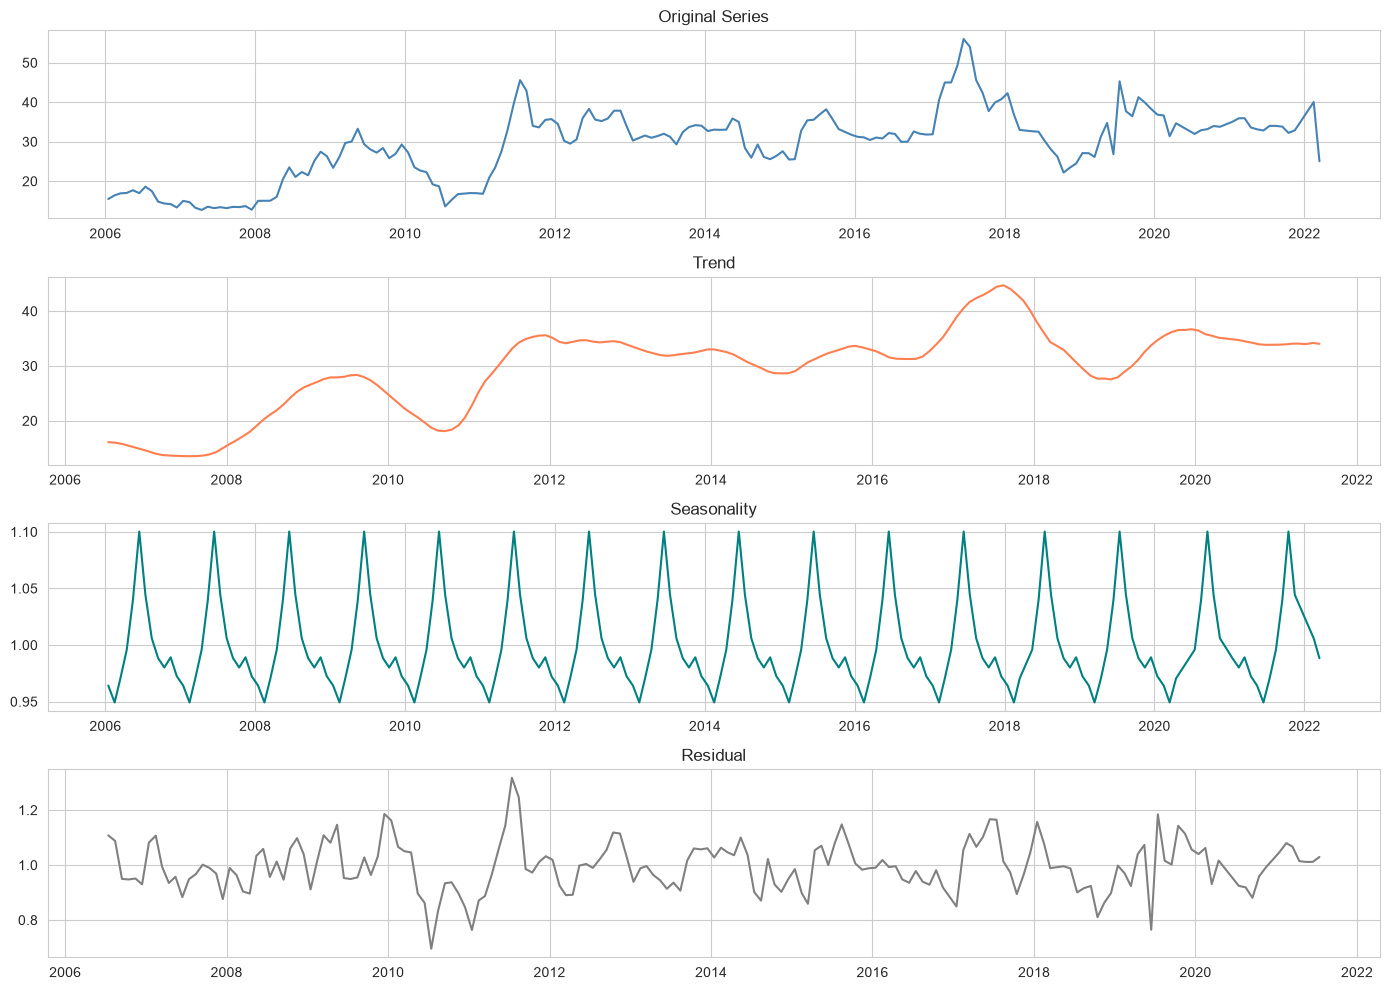

=== Augmented Dickey-Fuller Test ===
ADF Statistic: -2.7788
p-value: 0.0614

Series is NON-STATIONARY — need to difference before SARIMA
Apply d=1 in SARIMA(p,d,q)(P,D,Q,12)


In [17]:
#  Decomposition + Stationarity 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
fig, axes = plt.subplots(4, 1, figsize=(14, 10))

series = maize_nairobi.set_index('date')['price_per_kg']

# Decompose
result = seasonal_decompose(series, model='multiplicative', period=12)

axes[0].plot(series, color='steelblue')
axes[0].set_title('Original Series')

axes[1].plot(result.trend, color='coral')
axes[1].set_title('Trend')

axes[2].plot(result.seasonal, color='teal')
axes[2].set_title('Seasonality')

axes[3].plot(result.resid, color='grey')
axes[3].set_title('Residual')

plt.tight_layout()
plt.show()

# Stationarity test
adf_result = adfuller(series.dropna())
print('=== Augmented Dickey-Fuller Test ===')
print('ADF Statistic:', round(adf_result[0], 4))
print('p-value:', round(adf_result[1], 4))
print()
if adf_result[1] < 0.05:
    print('Series is STATIONARY — SARIMA can be applied directly')
else:
    print('Series is NON-STATIONARY — need to difference before SARIMA')
    print('Apply d=1 in SARIMA(p,d,q)(P,D,Q,12)')

After differencing:
ADF Statistic: -13.5065
p-value: 0.0
NOW STATIONARY — use d=1 in SARIMA


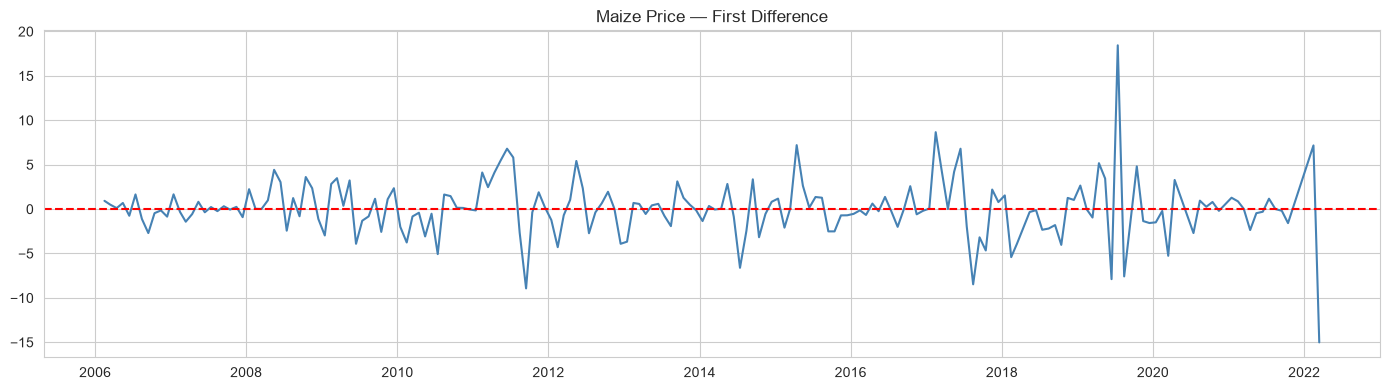

In [18]:
# Difference the series and retest
series_diff = series.diff().dropna()

adf_diff = adfuller(series_diff)
print('After differencing:')
print('ADF Statistic:', round(adf_diff[0], 4))
print('p-value:', round(adf_diff[1], 4))

if adf_diff[1] < 0.05:
    print('NOW STATIONARY — use d=1 in SARIMA')
else:
    print('Still non-stationary — try d=2')

# Plot differenced series
plt.figure(figsize=(14, 4))
plt.plot(series_diff, color='steelblue')
plt.title('Maize Price — First Difference')
plt.axhline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()